# IND320 — Project Work, Part 1

**GitHub repository:** https://github.com/isach07/IND320_isachstevik

**Streamlit app:** https://ind320isachstevik-dsj69wxyp9oamezekyfwal.streamlit.app

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# reading the data
df = pd.read_csv("../data/reservoirs.csv", parse_dates=["dato_Id"])
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [2]:
# rename columns into englsih and understanable names

df = df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_ratio",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "filling_twh",
    "neste_Publiseringsdato": "next_publish_date",
    "fyllingsgrad_forrige_uke": "fill_ratio_prev_week",
    "endring_fyllingsgrad": "fill_ratio_change",
})
df.head()

,date,area_type,area_number,iso_year,iso_week,fill_ratio,capacity_twh,filling_twh,next_publish_date,fill_ratio_prev_week,fill_ratio_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [3]:
# printing

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.describe()

Shape: (14877, 11)
Date range: 1995-01-08 00:00:00 to 2026-09-06 00:00:00


,date,area_number,iso_year,iso_week,fill_ratio,capacity_twh,filling_twh,fill_ratio_prev_week,fill_ratio_change
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385


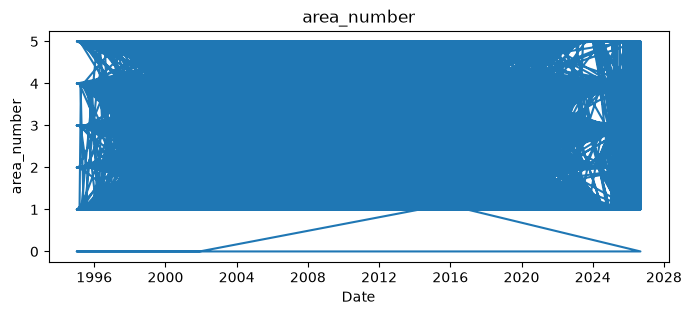

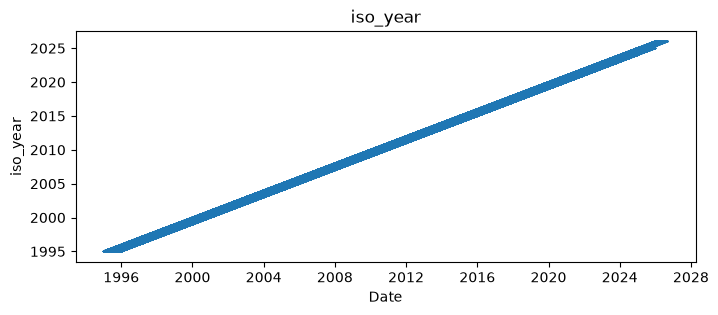

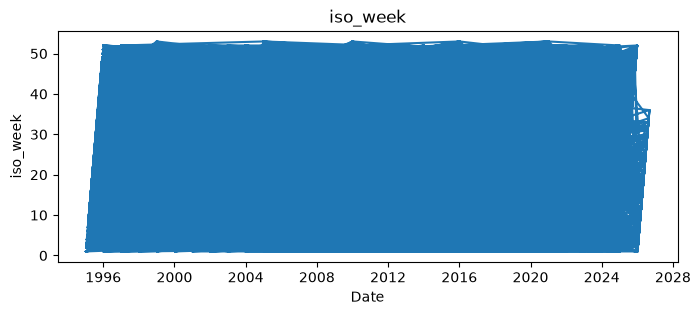

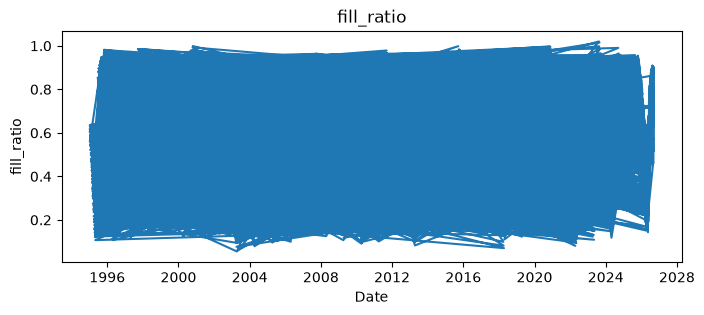

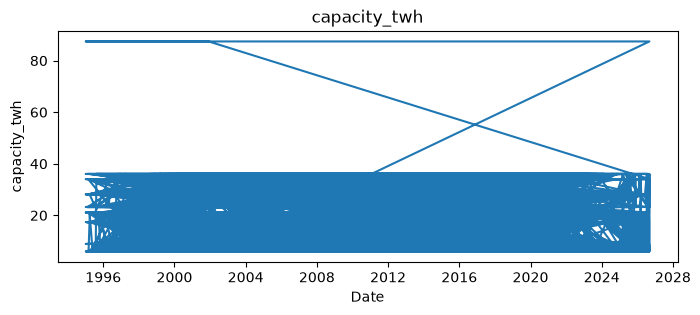

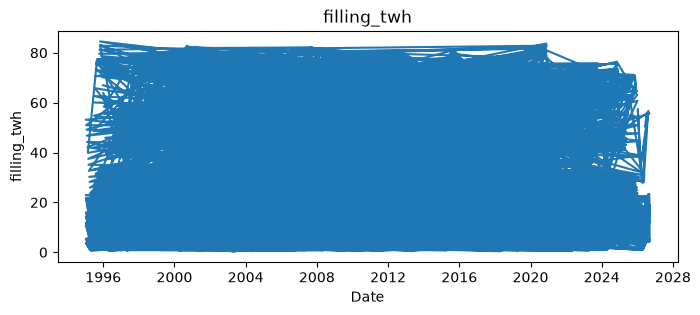

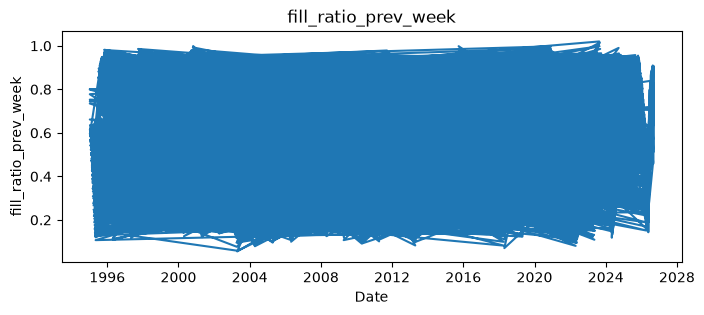

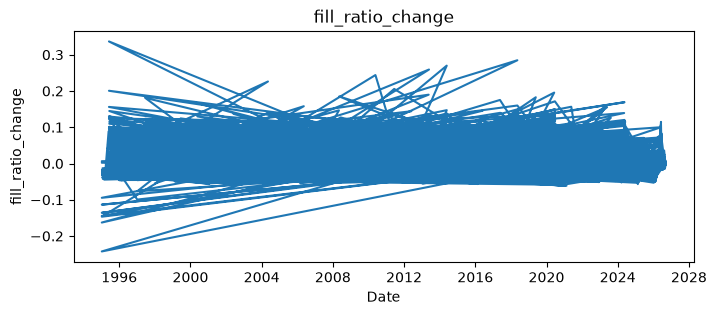

In [7]:
# plotting each column seperately

numeric_cols = df.select_dtypes("number").columns

for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(df["date"], df[col])
    ax.set_title(col)
    ax.set_xlabel("Date")
    ax.set_ylabel(col)
    plt.show()

## Plotting all columns together

Since the columns have very different scales (e.g. `fill_ratio` is between 0 and 1, while `capacity_twh` is in the tens), each column is normalized to a 0–1 range before plotting together, so they can be compared on one chart.

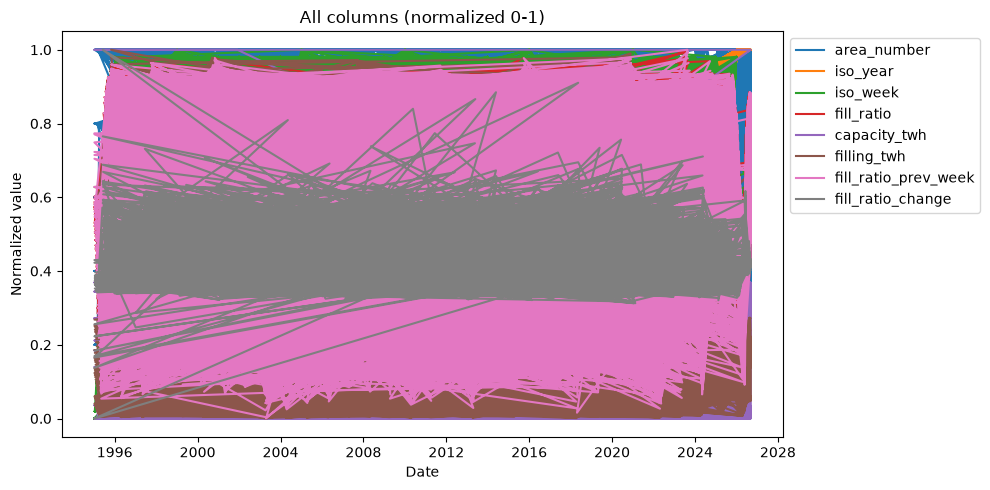

In [8]:
normalized = (df[numeric_cols] - df[numeric_cols].min()) / (df[numeric_cols].max() - df[numeric_cols].min())

fig, ax = plt.subplots(figsize=(10, 5))
for col in numeric_cols:
    ax.plot(df["date"], normalized[col], label=col)
ax.set_title("All columns (normalized 0-1)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized value")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## AI usage

*(Write 1-3 sentences here describing where/how you used AI — e.g. "Used Claude to help scaffold the Streamlit multi-page app structure and debug a git authentication issue.")*
i am using AI for hempling me generating code

## Log (300–500 words)

*(Describe what you did for this part of the project: setting up GitHub and Streamlit Cloud, building the 4-page app, reading and cleaning the reservoirs data, and your experience with both the notebook and Streamlit sides of the work.)*